### prep chai array-like

In [1]:
import pandas as pd
import yaml
from pathlib import Path

YAML_PATH = "/home/bri/pymol/EDA/static/metric_directions.yaml"
OUTPUT_DIR = Path("/home/bri/pymol/EDA/static/snir_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

CSV_PATH =  "/home/bri/pymol/EDA/static/snir_outputs/merged_snir.csv"
scores_df = pd.read_csv(CSV_PATH)

scores_df.head()

,source,type,sample,binder,KD[M],af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,...,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_ptm,chai_constrained_per_chain_pair_iptm
0,snir_ab,original,5ifj_abc_cut,1,0.000010,2.593883,95.404666,14.690,1.855,1.993750,...,0.278017,0.960036,0.937455,0.23935,0.96685,0.87115,"[[0.9473640322685242, 0.9504183530807495, 0.17...","[[[0.9473640322685242, 0.8909199237823486, 0.0...","[[0.9444541931152344, 0.9485954642295837, 0.17...","[[[0.9444541931152344, 0.8890032768249512, 0.0..."
1,snir_ab,original,5ig7_abc_cut,1,0.000100,2.572969,95.599717,8.050,1.025,2.020938,...,0.284754,0.952718,0.925141,0.23420,0.96935,0.85870,"[[0.9454975724220276, 0.9490044116973877, 0.17...","[[[0.9454975724220276, 0.8908762335777283, 0.0...","[[0.9449535012245178, 0.9492579102516174, 0.17...","[[[0.9449535012245178, 0.890431821346283, 0.07..."
2,snir_ab,original,5ijk_acx_cut,1,0.000001,3.486349,92.439163,26.435,4.765,5.111071,...,0.283189,0.943557,0.906099,0.08775,0.92390,0.82455,"[[0.9368650317192078, 0.9511184692382812, 0.10...","[[[0.9368650317192078, 0.886062502861023, 0.01...","[[0.9476516246795654, 0.9530132412910461, 0.13...","[[[0.9476516246795654, 0.8901079893112183, 0.0..."
3,snir_ab,alanine_scan,5ifj_abc_cut_A_D111A,0,NaN,2.815847,95.282854,13.225,1.745,2.100000,...,0.289870,0.943841,0.908519,0.21980,0.92900,0.85605,"[[0.9472975134849548, 0.9492976665496826, 0.17...","[[[0.9472975134849548, 0.8904723525047302, 0.0...","[[0.9474473595619202, 0.9492152333259583, 0.17...","[[[0.9474473595619202, 0.8894752264022827, 0.0..."
4,snir_ab,alanine_scan,5ifj_abc_cut_A_K110A,0,NaN,2.790728,94.871984,19.975,2.845,2.275417,...,0.275365,0.961354,0.939275,0.23650,0.96220,0.87810,"[[0.9461949467658997, 0.9488812685012817, 0.16...","[[[0.9461949467658997, 0.8897757530212402, 0.0...","[[0.9478796720504761, 0.9488250017166138, 0.17...","[[[0.9478796720504761, 0.888024091720581, 0.07..."


### prep chai array-like

In [2]:
chai_df = scores_df[['sample', 'chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm']]
chai_df.to_csv(OUTPUT_DIR / 'chai_matrices.csv', index=False)

In [3]:
chai_df.head()

,sample,chai_unconstrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_ptm,chai_constrained_per_chain_pair_iptm
0,5ifj_abc_cut,"[[0.9473640322685242, 0.9504183530807495, 0.17...","[[[0.9473640322685242, 0.8909199237823486, 0.0...","[[0.9444541931152344, 0.9485954642295837, 0.17...","[[[0.9444541931152344, 0.8890032768249512, 0.0..."
1,5ig7_abc_cut,"[[0.9454975724220276, 0.9490044116973877, 0.17...","[[[0.9454975724220276, 0.8908762335777283, 0.0...","[[0.9449535012245178, 0.9492579102516174, 0.17...","[[[0.9449535012245178, 0.890431821346283, 0.07..."
2,5ijk_acx_cut,"[[0.9368650317192078, 0.9511184692382812, 0.10...","[[[0.9368650317192078, 0.886062502861023, 0.01...","[[0.9476516246795654, 0.9530132412910461, 0.13...","[[[0.9476516246795654, 0.8901079893112183, 0.0..."
3,5ifj_abc_cut_A_D111A,"[[0.9472975134849548, 0.9492976665496826, 0.17...","[[[0.9472975134849548, 0.8904723525047302, 0.0...","[[0.9474473595619202, 0.9492152333259583, 0.17...","[[[0.9474473595619202, 0.8894752264022827, 0.0..."
4,5ifj_abc_cut_A_K110A,"[[0.9461949467658997, 0.9488812685012817, 0.16...","[[[0.9461949467658997, 0.8897757530212402, 0.0...","[[0.9478796720504761, 0.9488250017166138, 0.17...","[[[0.9478796720504761, 0.888024091720581, 0.07..."


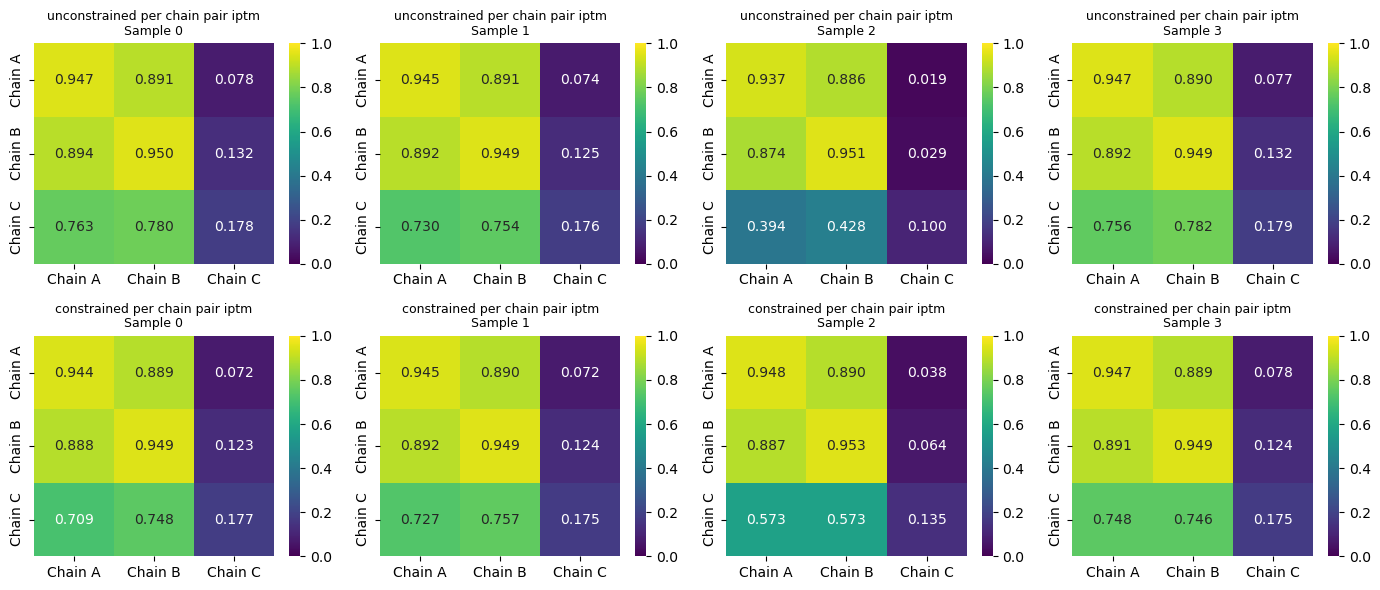

In [4]:
# Parse matrix strings from all 4 chai columns
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def parse_matrix(x):
    if pd.isna(x):
        return None
    try:
        arr = np.array(ast.literal_eval(x))
        return arr.squeeze()  # remove extra dimensions
    except:
        return None

# Apply parse_matrix to all 4 columns
ptm_cols = ['chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm']

for col in ptm_cols:
    chai_df[f"{col}_matrix"] = chai_df[col].apply(parse_matrix)

# Create heatmaps for first 4 samples (focusing on pair_iptm columns)
pair_cols = ['chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_pair_iptm']

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for row_idx, col in enumerate(pair_cols):
    for sample_idx in range(4):
        ax = axes[row_idx, sample_idx]
        matrix = chai_df[f"{col}_matrix"].iloc[sample_idx]
        
        if matrix is not None and isinstance(matrix, np.ndarray) and matrix.ndim == 2:
            n = matrix.shape[0]  # works for 2x2, 3x3, etc.
            labels = [f'Chain {chr(65+i)}' for i in range(n)]  # A, B, C, ...
            
            sns.heatmap(
                matrix,
                ax=ax,
                cmap='viridis',
                cbar=True,
                xticklabels=labels,
                yticklabels=labels,
                vmin=0,
                vmax=1,
                annot=True,
                fmt='.3f'
            )
            
            ax.set_title(
                f'{col.replace("chai_", "").replace("_", " ")}\nSample {sample_idx}',
                fontsize=9
            )
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])


plt.tight_layout()
plt.savefig(OUTPUT_DIR /'chai_matrices_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()



In [5]:
def extract_matrix_min(matrix):
    if matrix is None or not isinstance(matrix, np.ndarray) or matrix.ndim != 2:
        return np.nan

    n = matrix.shape[0]

    # germinal/mcmahon: only one interface (A-C or B-C)
    if n == 2:
        return np.min([matrix[0, 1], matrix[1, 0]])

    # snir: average C interactions with A and B
    elif n == 3:
        ac = np.min([matrix[0, 2], matrix[2, 0]])
        bc = np.min([matrix[1, 2], matrix[2, 1]])
        return np.min([ac, bc])

    return np.nan

chai_df['chai_unconstrained_per_chain_iptm'] = \
    chai_df['chai_unconstrained_per_chain_pair_iptm_matrix'].apply(extract_matrix_min)

chai_df['chai_constrained_per_chain_iptm'] = \
    chai_df['chai_constrained_per_chain_pair_iptm_matrix'].apply(extract_matrix_min)


# Display summary
print("Unconstrained A-B interface min (top 10):")
print(chai_df['chai_unconstrained_per_chain_iptm'].head(10).to_string())
print("\nConstrained A-B interface min (top 10):")
print(chai_df['chai_constrained_per_chain_iptm'].head(10).to_string())

Unconstrained A-B interface min (top 10):
0    0.077992
1    0.073652
2    0.019133
3    0.077001
4    0.077093
5    0.075082
6    0.055787
7    0.061475
8    0.014928
9    0.080386

Constrained A-B interface min (top 10):
0    0.072123
1    0.071622
2    0.037679
3    0.077862
4    0.074850
5    0.075991
6    0.076544
7    0.075928
8    0.074698
9    0.076364


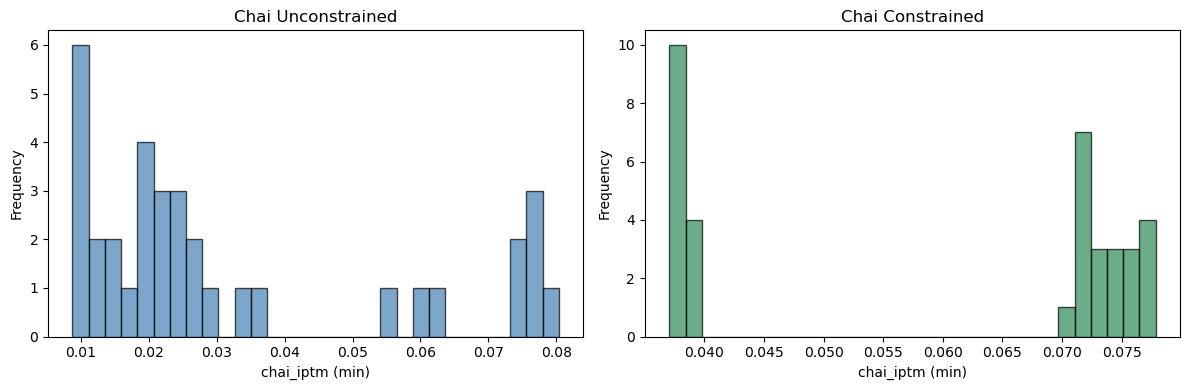

In [6]:
# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(chai_df['chai_unconstrained_per_chain_iptm'].dropna(), bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('chai_iptm (min)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Chai Unconstrained')
axes[0].grid(False)

axes[1].hist(chai_df['chai_constrained_per_chain_iptm'].dropna(), bins=30, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_xlabel('chai_iptm (min)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Chai Constrained')
axes[1].grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chai_iptm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Extract min pTM
def extract_ptm_min(arr):
    """Extract minimum of pTM array (average across both chains)"""
    if arr is None or not isinstance(arr, np.ndarray) or arr.ndim != 1:
        return np.nan
    return np.min(arr)

# Extract min for unconstrained pTM
chai_df['chai_unconstrained_per_chain_ptm'] = \
    chai_df['chai_unconstrained_per_chain_ptm_matrix'].apply(extract_ptm_min)

# Extract min for constrained pTM
chai_df['chai_constrained_per_chain_ptm'] = \
    chai_df['chai_constrained_per_chain_ptm_matrix'].apply(extract_ptm_min)

# Display summary

print("\nUnconstrained pTM min (top 10):")
print(chai_df['chai_unconstrained_per_chain_ptm'].head(10).to_string())
print("\nConstrained pTM min (top 10):")
print(chai_df['chai_constrained_per_chain_ptm'].head(10).to_string())
print(f"\nUnconstrained pTM min - desc stats:\n{chai_df['chai_unconstrained_per_chain_ptm'].describe()}")
print(f"\nConstrained pTM min - desc stats:\n{chai_df['chai_constrained_per_chain_ptm'].describe()}")


Unconstrained pTM min (top 10):
0    0.178244
1    0.175888
2    0.100218
3    0.178802
4    0.168942
5    0.178196
6    0.160372
7    0.164262
8    0.112114
9    0.174865

Constrained pTM min (top 10):
0    0.176853
1    0.175131
2    0.135256
3    0.175418
4    0.173193
5    0.172789
6    0.172529
7    0.172611
8    0.173503
9    0.172430

Unconstrained pTM min - desc stats:
count    35.000000
mean      0.117227
std       0.033312
min       0.088425
25%       0.094643
50%       0.099716
75%       0.139692
max       0.178802
Name: chai_unconstrained_per_chain_ptm, dtype: float64

Constrained pTM min - desc stats:
count    35.000000
mean      0.159089
std       0.019651
min       0.134094
25%       0.135356
50%       0.172789
75%       0.175258
max       0.178159
Name: chai_constrained_per_chain_ptm, dtype: float64


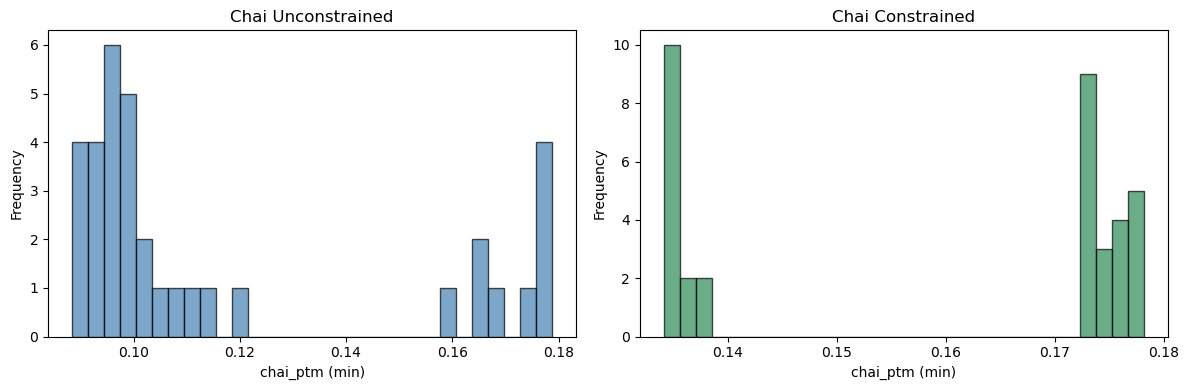

In [8]:
# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(chai_df['chai_unconstrained_per_chain_ptm'].dropna(), bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('chai_ptm (min)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Chai Unconstrained')
axes[0].grid(False)

axes[1].hist(chai_df['chai_constrained_per_chain_ptm'].dropna(), bins=30, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_xlabel('chai_ptm (min)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Chai Constrained')
axes[1].grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chai_ptm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Create df_chai_numeric with extracted mean scores 
df_chai_numeric = chai_df[['sample',
                            'chai_unconstrained_per_chain_ptm',
                            'chai_constrained_per_chain_ptm',
                            'chai_unconstrained_per_chain_iptm',
                            'chai_constrained_per_chain_iptm']].copy()

print("df_chai_numeric shape:", df_chai_numeric.shape)
print("\ndf_chai_numeric head:")
print(df_chai_numeric.head(10).to_string())
print("\ndf_chai_numeric info:")
print(df_chai_numeric.info())

# Save to CSV
df_chai_numeric.to_csv(OUTPUT_DIR / 'chai_numeric_metrics.csv', index=False)
print("\n✓ Saved to: chai_numeric_metrics.csv")

df_chai_numeric shape: (35, 5)

df_chai_numeric head:
                 sample  chai_unconstrained_per_chain_ptm  chai_constrained_per_chain_ptm  chai_unconstrained_per_chain_iptm  chai_constrained_per_chain_iptm
0          5ifj_abc_cut                          0.178244                        0.176853                           0.077992                         0.072123
1          5ig7_abc_cut                          0.175888                        0.175131                           0.073652                         0.071622
2          5ijk_acx_cut                          0.100218                        0.135256                           0.019133                         0.037679
3  5ifj_abc_cut_A_D111A                          0.178802                        0.175418                           0.077001                         0.077862
4  5ifj_abc_cut_A_K110A                          0.168942                        0.173193                           0.077093                         0.07485

In [10]:
scores_df.drop(columns=['chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm'], inplace = True)
scores_df.head()

,source,type,sample,binder,KD[M],af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,...,boltz_template_iptm,boltz_template_plddt,boltz_template_iplddt,boltz_template_pde,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis
0,snir_ab,original,5ifj_abc_cut,1,0.000010,2.593883,95.404666,14.690,1.855,1.993750,...,0.986901,0.985055,0.985220,0.256930,0.278017,0.960036,0.937455,0.23935,0.96685,0.87115
1,snir_ab,original,5ig7_abc_cut,1,0.000100,2.572969,95.599717,8.050,1.025,2.020938,...,0.985429,0.987334,0.987299,0.258769,0.284754,0.952718,0.925141,0.23420,0.96935,0.85870
2,snir_ab,original,5ijk_acx_cut,1,0.000001,3.486349,92.439163,26.435,4.765,5.111071,...,0.986835,0.982311,0.979760,0.255680,0.283189,0.943557,0.906099,0.08775,0.92390,0.82455
3,snir_ab,alanine_scan,5ifj_abc_cut_A_D111A,0,NaN,2.815847,95.282854,13.225,1.745,2.100000,...,0.987563,0.979963,0.975488,0.256625,0.289870,0.943841,0.908519,0.21980,0.92900,0.85605
4,snir_ab,alanine_scan,5ifj_abc_cut_A_K110A,0,NaN,2.790728,94.871984,19.975,2.845,2.275417,...,0.987761,0.983894,0.983133,0.254981,0.275365,0.961354,0.939275,0.23650,0.96220,0.87810


In [11]:
# Join scores_df with df_chai_numeric on "sample"
scores_df_extended = scores_df.merge(df_chai_numeric, on='sample', how='left')

print("Joined DataFrame shape:", scores_df_extended.shape)
print("\nNew columns added from df_chai_numeric:")
new_cols = [col for col in scores_df_extended.columns if col in df_chai_numeric.columns and col != 'sample']
print(new_cols)
print("\nscores_df_extended head:")
print(scores_df_extended[['sample'] + new_cols].head(10).to_string())
print("\nJoin statistics:")
print(f"  - Total rows: {len(scores_df_extended)}")
print(f"  - Rows with all chai metrics: {scores_df_extended[new_cols].notna().all(axis=1).sum()}")
print(f"  - Rows with missing chai metrics: {scores_df_extended[new_cols].isna().any(axis=1).sum()}")

# Save extended dataframe
scores_df_extended.to_csv(OUTPUT_DIR / 'scores_df_extended_with_chai.csv', index=False)
print(f"\n✓ Saved to: {OUTPUT_DIR / 'scores_df_extended_with_chai.csv'}")

Joined DataFrame shape: (35, 90)

New columns added from df_chai_numeric:
['chai_unconstrained_per_chain_ptm', 'chai_constrained_per_chain_ptm', 'chai_unconstrained_per_chain_iptm', 'chai_constrained_per_chain_iptm']

scores_df_extended head:
                 sample  chai_unconstrained_per_chain_ptm  chai_constrained_per_chain_ptm  chai_unconstrained_per_chain_iptm  chai_constrained_per_chain_iptm
0          5ifj_abc_cut                          0.178244                        0.176853                           0.077992                         0.072123
1          5ig7_abc_cut                          0.175888                        0.175131                           0.073652                         0.071622
2          5ijk_acx_cut                          0.100218                        0.135256                           0.019133                         0.037679
3  5ifj_abc_cut_A_D111A                          0.178802                        0.175418                           0.077001 

In [12]:
scores_df_extended.head()

,source,type,sample,binder,KD[M],af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,...,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_iptm,chai_constrained_per_chain_iptm
0,snir_ab,original,5ifj_abc_cut,1,0.000010,2.593883,95.404666,14.690,1.855,1.993750,...,0.278017,0.960036,0.937455,0.23935,0.96685,0.87115,0.178244,0.176853,0.077992,0.072123
1,snir_ab,original,5ig7_abc_cut,1,0.000100,2.572969,95.599717,8.050,1.025,2.020938,...,0.284754,0.952718,0.925141,0.23420,0.96935,0.85870,0.175888,0.175131,0.073652,0.071622
2,snir_ab,original,5ijk_acx_cut,1,0.000001,3.486349,92.439163,26.435,4.765,5.111071,...,0.283189,0.943557,0.906099,0.08775,0.92390,0.82455,0.100218,0.135256,0.019133,0.037679
3,snir_ab,alanine_scan,5ifj_abc_cut_A_D111A,0,NaN,2.815847,95.282854,13.225,1.745,2.100000,...,0.289870,0.943841,0.908519,0.21980,0.92900,0.85605,0.178802,0.175418,0.077001,0.077862
4,snir_ab,alanine_scan,5ifj_abc_cut_A_K110A,0,NaN,2.790728,94.871984,19.975,2.845,2.275417,...,0.275365,0.961354,0.939275,0.23650,0.96220,0.87810,0.168942,0.173193,0.077093,0.074850
